<a href="https://colab.research.google.com/github/athrav138/Data-Science-Internship-Soft-Tech-12-Weeks/blob/main/Video_Games_Sales_EDA_%26_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import matplotlib.pyplot as plt


In [34]:
df = pd.read_csv("cleaned_vgsales.csv")
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16535,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16536,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16537,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16538,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


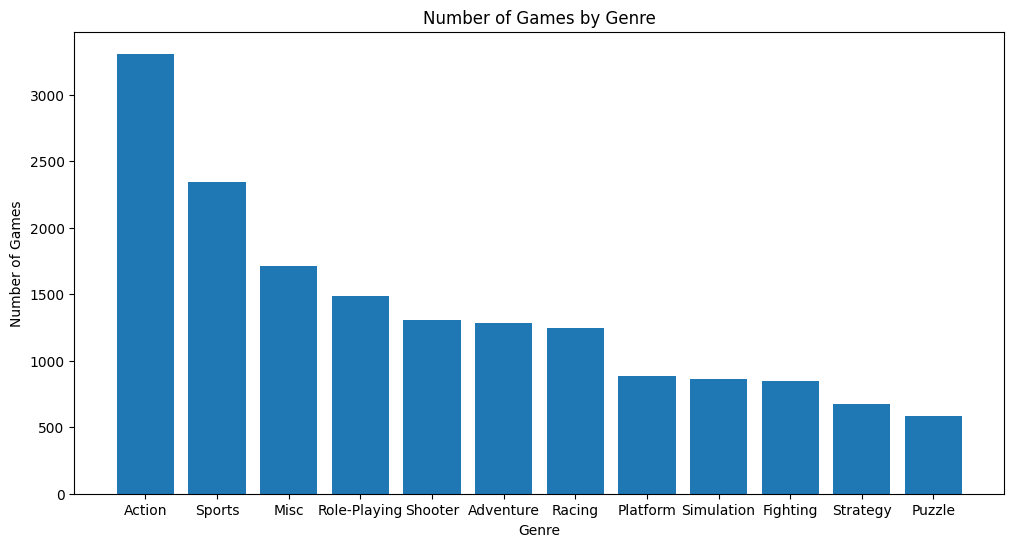

In [35]:
# Number of Games by Genre
plt.figure(figsize=(12,6))
genre_counts = df["Genre"].value_counts()
plt.bar(genre_counts.index, genre_counts.values)
plt.xlabel("Genre")
plt.ylabel("Number of Games")
plt.title("Number of Games by Genre")
plt.show()

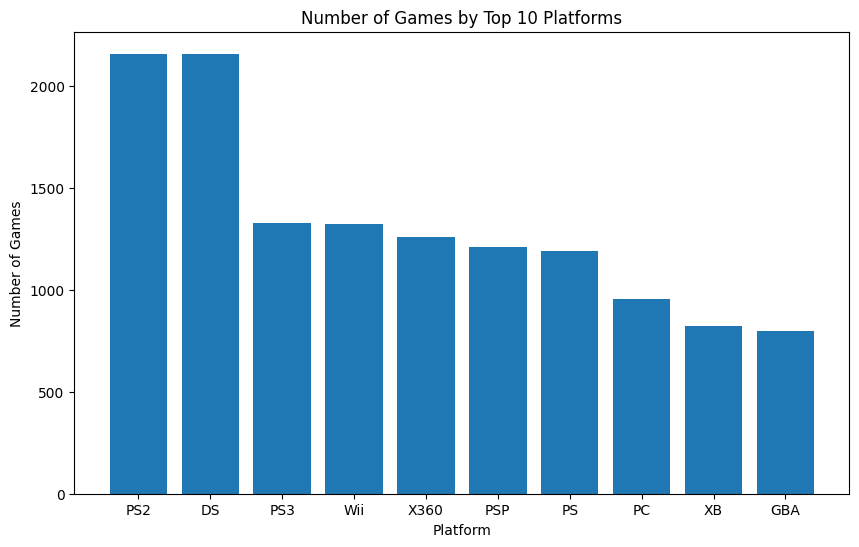

In [36]:
# Top 10 Platforms

plt.figure(figsize=(10,6))
plt.bar(
    platform_counts.index,
    platform_counts.values
)
plt.xlabel("Platform")
plt.ylabel("Number of Games")
plt.title("Number of Games by Top 10 Platforms")
plt.show()

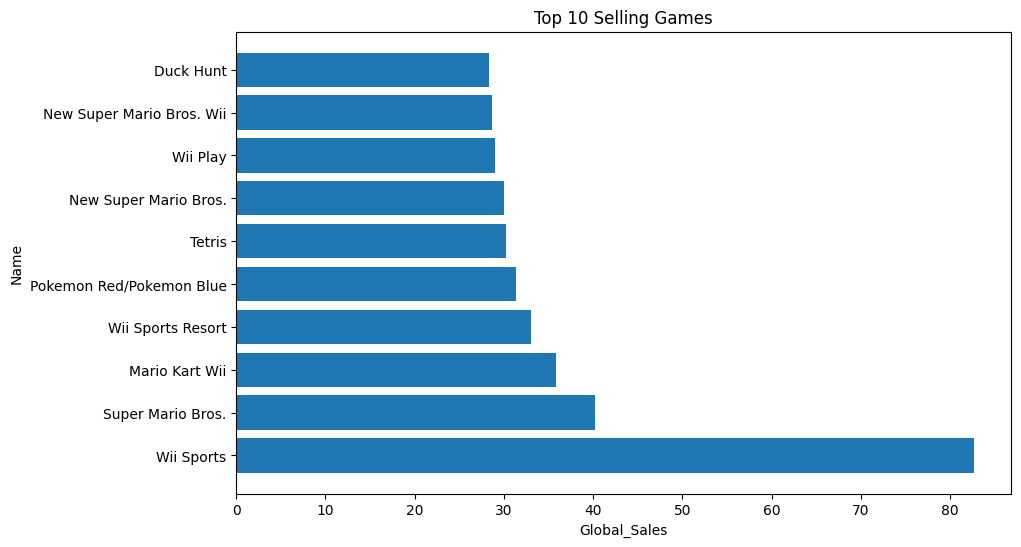

In [37]:
# Top 10 Selling games
top_games = df.nlargest(
    10,
    "Global_Sales"
)
plt.figure(figsize=(10,6))
plt.barh(
    top_games["Name"],
    top_games["Global_Sales"]
)
plt.xlabel("Global_Sales")
plt.ylabel("Name")
plt.title("Top 10 Selling Games")
plt.show()

## 4. Top Publishers by Sales

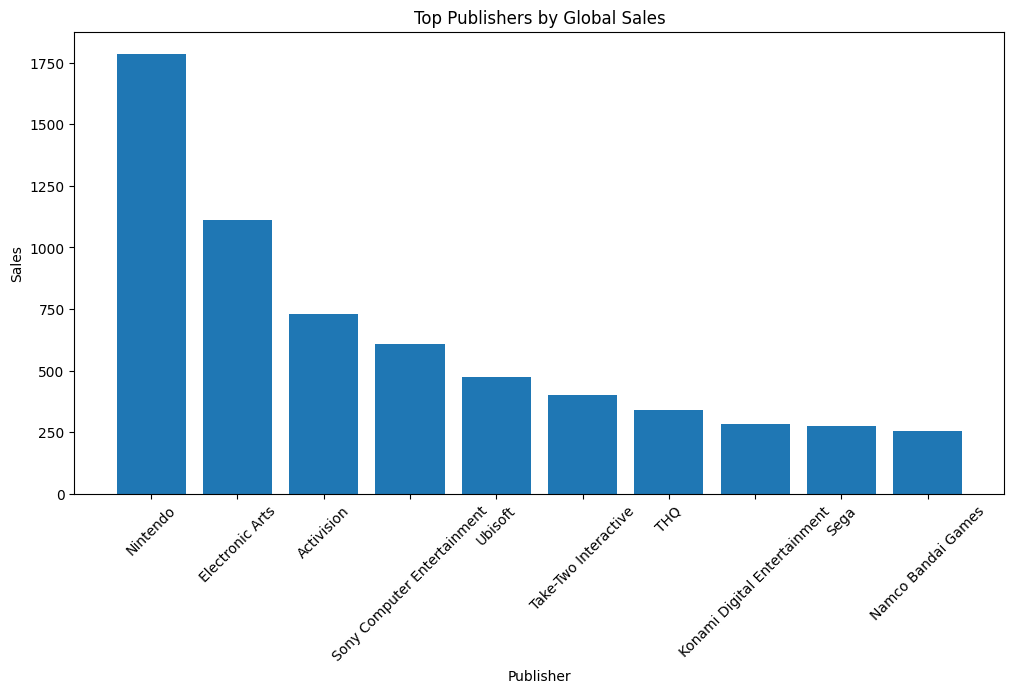

In [38]:
publisher_sales = (
    df.groupby("Publisher")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    publisher_sales.index,
    publisher_sales.values
)

plt.title("Top Publishers by Global Sales")
plt.xlabel("Publisher")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

## 5. Regional Sales Analysis (Pie Chart)

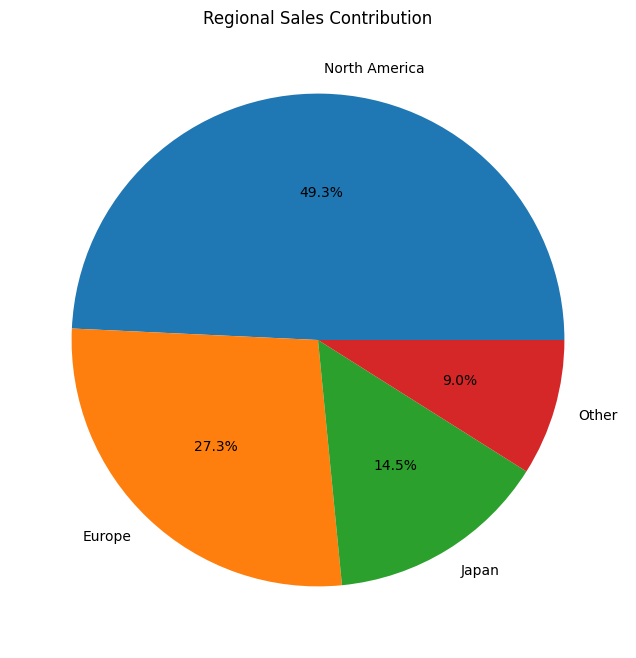

In [39]:
sales = [
    df["NA_Sales"].sum(),
    df["EU_Sales"].sum(),
    df["JP_Sales"].sum(),
    df["Other_Sales"].sum()
]

regions = [
    "North America",
    "Europe",
    "Japan",
    "Other"
]

plt.figure(figsize=(8,8))

plt.pie(
    sales,
    labels=regions,
    autopct="%1.1f%%"
)

plt.title("Regional Sales Contribution")

plt.show()

## 6. Genre vs Global Sales

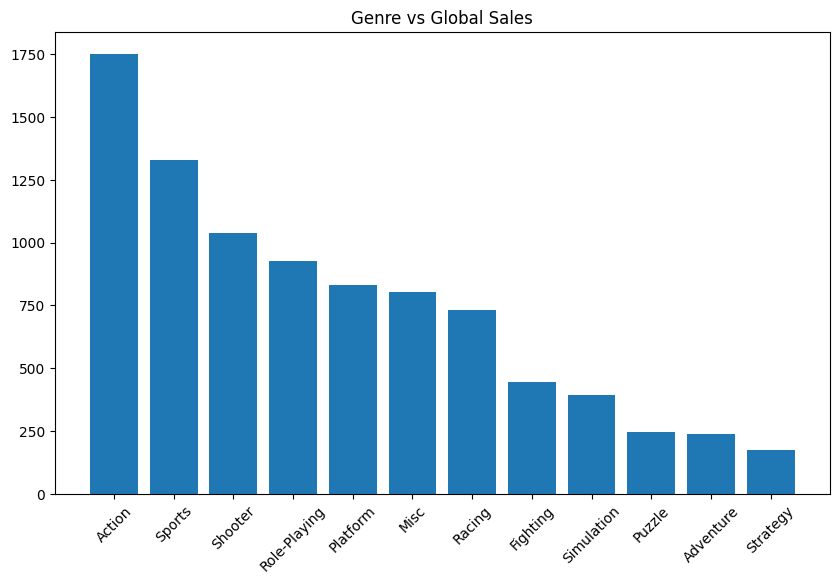

In [40]:
genre_sales = (
    df.groupby("Genre")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    genre_sales.index,
    genre_sales.values
)

plt.title("Genre vs Global Sales")

plt.xticks(rotation=45)

plt.show()

## 7. Platform vs Global Sales

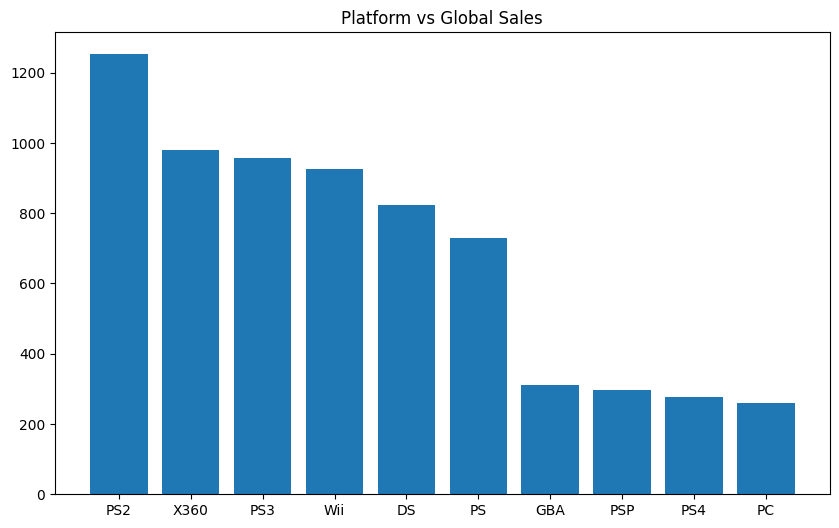

In [41]:
platform_sales = (
    df.groupby("Platform")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    platform_sales.index,
    platform_sales.values
)

plt.title("Platform vs Global Sales")

plt.show()

## 8. Yearly Sales Trend

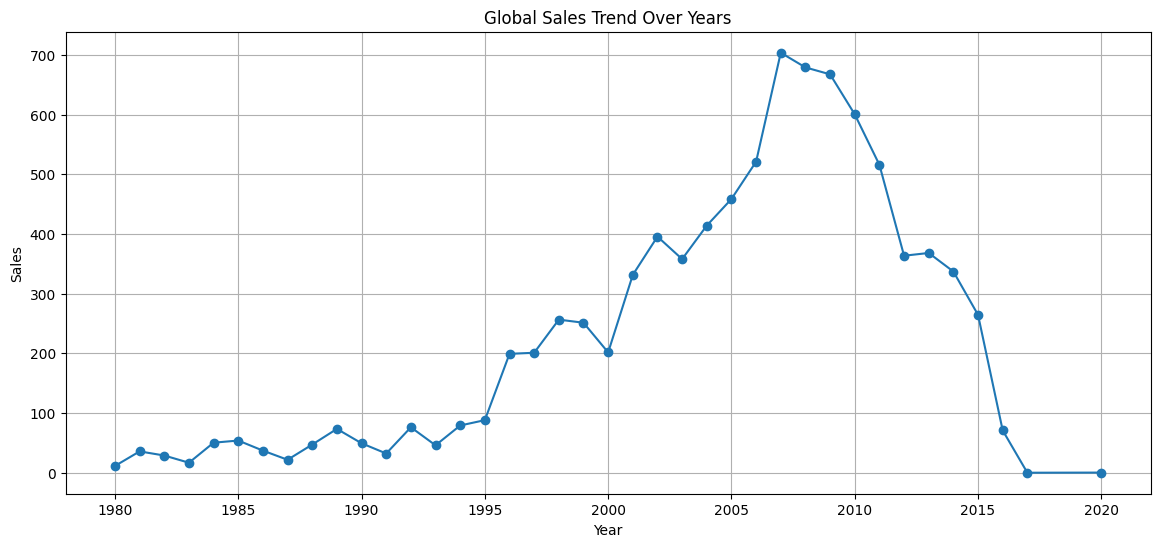

In [42]:
year_sales = (
    df.groupby("Year")["Global_Sales"]
    .sum()
)

plt.figure(figsize=(14,6))

plt.plot(
    year_sales.index,
    year_sales.values,
    marker="o"
)

plt.title("Global Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid()

plt.show()

## 9. Feature Engineering for Decade and Sales Categories

In [43]:
# Ensure 'Year' column is numeric, handling potential non-numeric entries
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
# Drop rows where 'Year' could not be converted to a number (NaN)
df.dropna(subset=['Year'], inplace=True)
# Convert 'Year' to integer
df['Year'] = df['Year'].astype(int)

df["Decade"] = (df["Year"] // 10) * 10

def get_top_region(row):
    sales = {'NA_Sales': row['NA_Sales'], 'EU_Sales': row['EU_Sales'], 'JP_Sales': row['JP_Sales'], 'Other_Sales': row['Other_Sales']}
    if not sales:
        return None
    return max(sales, key=sales.get)

df["Top_Region"] = df.apply(get_top_region, axis=1)

def get_sales_category(sales):
    if sales >= 10:
        return "High Sales"
    elif sales >= 1:
        return "Medium Sales"
    else:
        return "Low Sales"

df["Sales_Category"] = df["Global_Sales"].apply(get_sales_category)

df[['Year', 'Decade', 'Top_Region', 'Sales_Category']].head()

,Year,Decade,Top_Region,Sales_Category
0,2006,2000,NA_Sales,High Sales
1,1985,1980,NA_Sales,High Sales
2,2008,2000,NA_Sales,High Sales
3,2009,2000,NA_Sales,High Sales
4,1996,1990,NA_Sales,High Sales


## 10. Decade Analysis

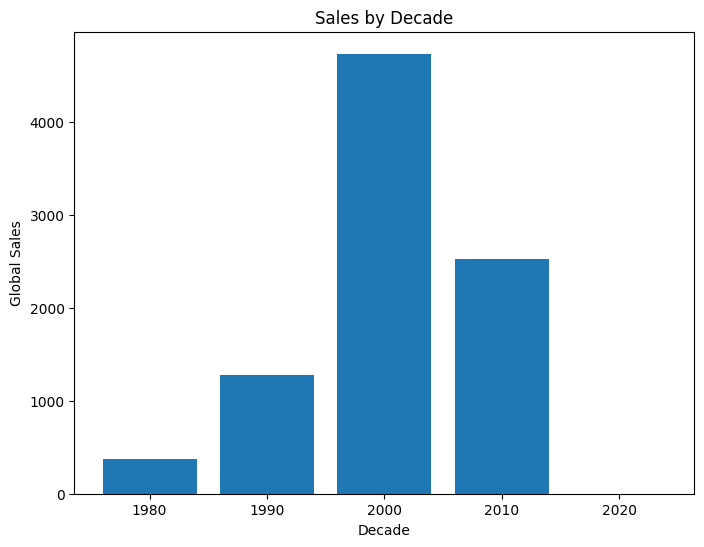

In [44]:
decade_sales = (
    df.groupby("Decade")["Global_Sales"]
    .sum()
)

plt.figure(figsize=(8,6))

plt.bar(
    decade_sales.index.astype(str),
    decade_sales.values
)

plt.title("Sales by Decade")
plt.xlabel("Decade")
plt.ylabel("Global Sales")

plt.show()

## 11. Correlation Heatmap (Matplotlib Only)

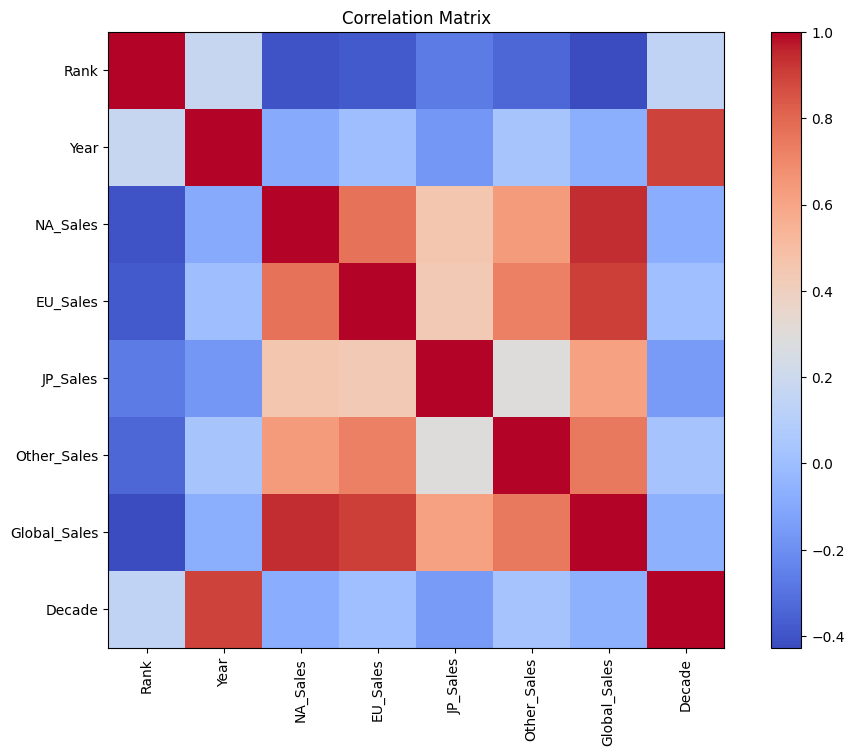

In [45]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

plt.imshow(
    corr,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()

## Bonus Visualizations (Highly Recommended)

### Top 10 Genres by Revenue

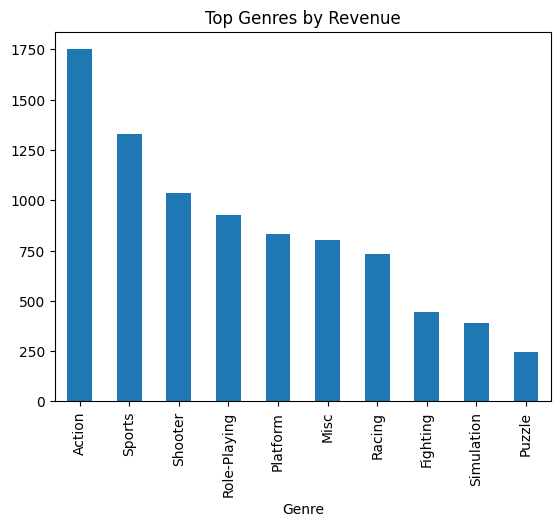

In [46]:
genre_sales.head(10).plot(
    kind="bar"
)

plt.title("Top Genres by Revenue")

plt.show()

### Top Region for Games

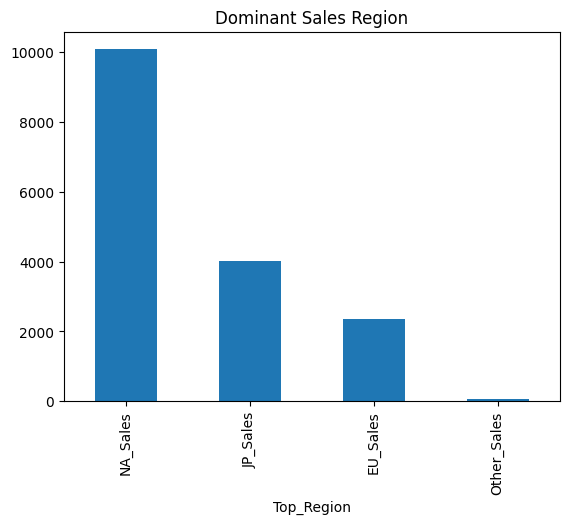

In [47]:
df["Top_Region"].value_counts().plot(
    kind="bar"
)

plt.title("Dominant Sales Region")

plt.show()

### Sales Category Distribution

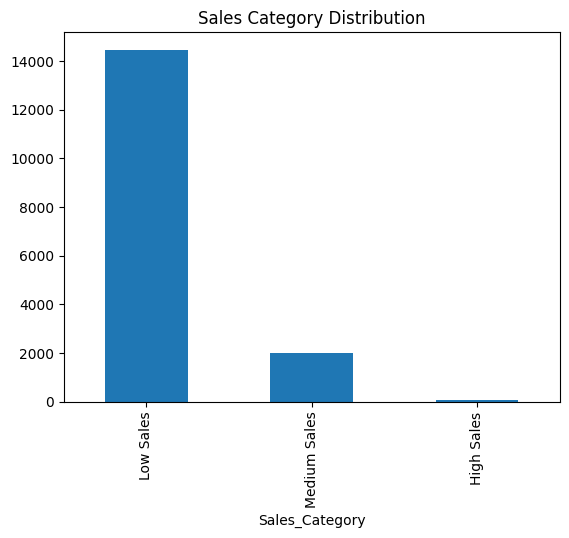

In [48]:
df["Sales_Category"].value_counts().plot(
    kind="bar"
)

plt.title("Sales Category Distribution")

plt.show()

Business Insights

Here are some initial business insights based on the visualizations:

*   **Action** and **Sports** are the most dominant genres in terms of both the number of games and global sales, indicating a strong market for these categories.
*   **PS2** and **DS** have historically been the most prolific platforms in terms of game releases, suggesting their widespread adoption during their peak. However, **PS2** also leads in global sales, indicating strong monetization.
*   **Wii Sports** is an outlier in global sales, significantly outperforming other games. This highlights the impact of bundled games and console-selling titles.
*   **Nintendo** and **Electronic Arts** are the leading publishers by global sales, reflecting their long-standing presence and successful franchises in the gaming industry.
*   **North America** contributes the largest share to global sales, followed by Europe and Japan. This suggests that marketing and localization efforts should be prioritized for these regions.
*   Global sales show a clear upward trend from the 1980s, peaking in the late 2000s, and then declining. This could be attributed to market saturation, shifts to new gaming models (e.g., mobile, free-to-play), or changes in data collection.
*   The **2000-2009 decade** was the most lucrative for video game sales, aligning with the peak observed in the yearly sales trend.
*   The correlation matrix suggests a strong positive correlation between regional sales (NA_Sales, EU_Sales, JP_Sales, Other_Sales) and Global_Sales, as expected. There might be a slight negative correlation between Rank and sales, meaning lower ranks (higher sales) are associated with higher sales, which is also expected. The correlation with 'Year' is relatively weak across most sales metrics, suggesting that age alone doesn't strongly determine individual game sales success over time, but rather market trends.
*   A large majority of games fall into the 'Low Sales' category, indicating a highly competitive market where only a few titles achieve 'High Sales'.

Conclusion

This Exploratory Data Analysis (EDA) of video game sales data provides a comprehensive overview of key trends and patterns in the industry. We've identified popular genres, dominant platforms, top-selling games, and major publishers. Regional sales contributions and historical sales trends highlight the dynamic nature of the market. The feature engineering for 'Decade', 'Top_Region', and 'Sales_Category' further enriches our understanding of the dataset. This analysis serves as a strong foundation for further investigations, such as predictive modeling for sales forecasting or deeper dives into specific market segments. The insights gathered can be valuable for game developers, publishers, and investors in making informed decisions.